<a href="https://colab.research.google.com/github/IbrahemAmar/KinneretGuardian-IoT/blob/main/KinneretGuardian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gradio pykrige pyproj statsmodels scikit-learn pandas numpy matplotlib openpyxl scipy python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 6.9 MB/s eta 0:00:00


In [2]:
# ==============================================================================
# 🌊 CELL 1: DEPENDENCIES
# ==============================================================================
print("⏳ מתקין ספריות...")
!pip -q install gradio pykrige pyproj statsmodels scikit-learn pandas numpy matplotlib openpyxl scipy python-bidi

import os, time, random, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import gradio as gr
from urllib.parse import quote
from pyproj import Transformer
from pykrige.ok import OrdinaryKriging
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, confusion_matrix, accuracy_score
from scipy.stats import spearmanr

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Tahoma', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 🔤 תיקון קריטי לכיווניות עברית בגרפים
try:
    from bidi.algorithm import get_display
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, "-m", "pip", "install", "-q", "python-bidi"])
    from bidi.algorithm import get_display

def he(text):
    return get_display(str(text))

print("✅ כל הספריות הוטענו בהצלחה!")

⏳ מתקין ספריות...
✅ כל הספריות הוטענו בהצלחה!


In [3]:
# ==============================================================================
# 📥 CELL 1.5: הורדת נתונים אוטומטית מ-GitHub
# ==============================================================================
import os
import urllib.request

print("📥 מוריד נתונים ישירות מ-GitHub...")

GITHUB_RAW_URL = "https://raw.githubusercontent.com/IbrahemAmar/KinneretGuardian-IoT/main/"

FILES_TO_DOWNLOAD = [
    "data_202606172157.xlsx",
    "KNW08_Waves.xlsx",
    "KNW09_Waves.xlsx",
    "KNW10_Waves.xlsx",
    "KNW11_Waves.xlsx",
    "KNW12_Waves.xlsx"
]

for filename in FILES_TO_DOWNLOAD:
    if not os.path.exists(filename):
        print(f"   מוריד את {filename}...")
        url = GITHUB_RAW_URL + filename.replace(" ", "%20")
        try:
            urllib.request.urlretrieve(url, filename)
        except Exception as e:
            print(f"❌ שגיאה בהורדת {filename}: {e}")
    else:
        print(f"   ✅ {filename} כבר קיים בסביבת העבודה.")

print("🎉 כל הקבצים הורדו בהצלחה ומוכנים לשימוש!")

📥 מוריד נתונים ישירות מ-GitHub...
   מוריד את data_202606172157.xlsx...
   מוריד את KNW08_Waves.xlsx...
   מוריד את KNW09_Waves.xlsx...
   מוריד את KNW10_Waves.xlsx...
   מוריד את KNW11_Waves.xlsx...
   מוריד את KNW12_Waves.xlsx...
🎉 כל הקבצים הורדו בהצלחה ומוכנים לשימוש!


In [4]:
# ==============================================================================
# 📡 CELL 1.7: IMS LIVE API — REAL-TIME WIND DATA
# ==============================================================================
import requests, numpy as np

IMS_API_TOKEN  = "1a901e45-9028-44ff-bd2c-35e82407fb9b"
IMS_STATION_ID = 8

def fetch_ims_live():
    """Return live wind data dict or None on any failure."""
    if (not IMS_STATION_ID
            or not IMS_API_TOKEN
            or IMS_API_TOKEN == "YOUR_TOKEN_HERE"):
        return None
    url = (f"https://api.ims.gov.il/v1/envista/stations/"
           f"{IMS_STATION_ID}/data/latest")
    try:
        r = requests.get(
            url,
            headers={"Authorization": f"ApiToken {IMS_API_TOKEN}"},
            timeout=8,
        )
        r.raise_for_status()
        channels = r.json()["data"][0]["channels"]
        result = {}
        for ch in channels:
            if ch["name"] == "WS":  result["Ws"]  = float(ch["value"])
            if ch["name"] == "WD":  result["Wd"]  = float(ch["value"])
        if "Ws" in result and "Wd" in result:
            wd_rad            = np.deg2rad(result["Wd"])
            result["U_east"]  = -(result["Ws"] * np.sin(wd_rad))
            result["source"]  = "\U0001f7e2 IMS LIVE"
            return result
    except Exception:
        return None
    return None


def list_kinneret_stations():
    """Helper — run once to find the correct station ID."""
    r = requests.get(
        "https://api.ims.gov.il/v1/envista/stations",
        headers={"Authorization": f"ApiToken {IMS_API_TOKEN}"},
    )
    df = pd.DataFrame(r.json()["stations"])
    mask = df["name"].str.contains(
        "Zemah|Kinneret|Tiberias|Golan|Ginosar|Degania",
        case=False, na=False,
    )
    print(df[mask][["stationId", "name", "location"]])

print("📡 CELL 1.7 loaded — IMS Live API ready (token required)")


📡 CELL 1.7 loaded — IMS Live API ready (token required)


In [5]:
# ==============================================================================
# 🌊 CELL 2: DATA ACQUISITION, CLEANING & ARX MODEL TRAINING
# ==============================================================================
print("📡 טוען נתוני רוח (לב כנרת) וגלים (KNW) ומסנכרן...")

WIND_FILE  = "data_202606172157.xlsx"
WAVE_FILES = sorted(glob.glob("KNW*_Waves.xlsx"))

if not os.path.exists(WIND_FILE) or not WAVE_FILES:
    raise FileNotFoundError("❌ קבצים חסרים. ודא ש-CELL 1.5 רץ בהצלחה.")

STATIONS_GEOG = {
    "Lev_Kinneret": (32.822, 35.591),
    "Bteha":        (32.887, 35.624),
    "Zemah":        (32.706, 35.577),
    "Ginosar":      (32.861, 35.520),
    "Ein_Gev":      (32.777, 35.646),
}

# 1) טעינת גלים
wave_frames = []
for f in WAVE_FILES:
    df = pd.read_excel(f, engine="openpyxl")
    tcol = next((c for c in df.columns if "Date" in str(c) or "Time" in str(c)), df.columns[0])
    hcol = next((c for c in df.columns if str(c).startswith("Hs")), None)
    if hcol is None: continue
    tmp = df[[tcol, hcol]].copy()
    tmp.columns = ["time", "Hs"]
    wave_frames.append(tmp)

waves = pd.concat(wave_frames, ignore_index=True)
waves["time"] = pd.to_datetime(waves["time"], errors="coerce")
waves["Hs"]   = pd.to_numeric(waves["Hs"], errors="coerce")
waves = waves.dropna()
waves = waves[(waves["Hs"] >= 0) & (waves["Hs"] <= 1.2)]
waves["time"] = waves["time"].dt.floor("h")
waves = waves.drop_duplicates("time").sort_values("time")

# 2) טעינת רוח
wind = pd.read_excel(WIND_FILE, engine="openpyxl")
ren = {"תאריך ושעה (שעון קיץ)": "time", "מהירות רוח (מטר לשניה)": "Ws", "כיוון הרוח (מעלות)": "Wd"}
wind = wind.rename(columns=ren)
wind["time"] = pd.to_datetime(wind["time"], dayfirst=True, errors="coerce")
wind["Ws"]   = pd.to_numeric(wind["Ws"], errors="coerce")
wind["Wd"]   = pd.to_numeric(wind["Wd"], errors="coerce")
wind = wind.dropna(subset=["time", "Ws", "Wd"])

wind["time_gmt"] = wind["time"] - pd.Timedelta(hours=3)
wind["Wd_rad"] = np.deg2rad(wind["Wd"])
wind["U_wind"] = wind["Ws"] * np.sin(wind["Wd_rad"])
wind["V_wind"] = wind["Ws"] * np.cos(wind["Wd_rad"])
wind["U_east"] = -wind["U_wind"]

wind_h = (wind.groupby(wind["time_gmt"].dt.floor("h"))
              .agg(Ws=("Ws", "mean"), U_wind=("U_wind", "mean"), V_wind=("V_wind", "mean"), U_east=("U_east", "mean"))
              .reset_index().rename(columns={"time_gmt": "time"}))

# 3) מיזוג
df_merged = wind_h.merge(waves, on="time", how="inner").sort_values("time").reset_index(drop=True)

# 4) אימון מודל ARX
LAG_RANGE = range(0, 25)
ccf = {lag: df_merged["Hs"].corr(df_merged["U_east"].shift(lag)) for lag in LAG_RANGE}
BEST_LAG = max(ccf, key=lambda k: abs(ccf[k])) # צפוי להיות 1

df_merged["U_east_lag"] = df_merged["U_east"].shift(BEST_LAG)
df_merged["Hs_prev"]    = df_merged["Hs"].shift(BEST_LAG)
df_reg = df_merged.dropna(subset=["Hs", "U_east_lag", "Hs_prev"]).reset_index(drop=True)

split = int(len(df_reg) * 0.8)
train, test = df_reg.iloc[:split], df_reg.iloc[split:]

Xtr = sm.add_constant(train[["Hs_prev", "U_east_lag"]])
arx_model = sm.OLS(train["Hs"], Xtr).fit()

Xte  = sm.add_constant(test[["Hs_prev", "U_east_lag"]])
pred = arx_model.predict(Xte)
TEST_R2  = r2_score(test["Hs"], pred)

ARX_ALPHA = arx_model.params["Hs_prev"]
ARX_BETA  = arx_model.params["U_east_lag"]
ARX_GAMMA = arx_model.params["const"]

print(f"✅ מודל ARX אומן בהצלחה! (R2={arx_model.rsquared:.3f}, Lag={BEST_LAG}h)")

📡 טוען נתוני רוח (לב כנרת) וגלים (KNW) ומסנכרן...
✅ מודל ARX אומן בהצלחה! (R2=0.718, Lag=1h)


In [6]:
# ==============================================================================
# 🌊 CELL 3: ANALYTICAL ENGINES (PCA, CCF, KRIGING)
# ==============================================================================
print("📐 מרכיב מנועי חישוב סטטיסטיים...")

def get_pca_plots():
    pca_vars = ["Ws", "U_wind", "V_wind", "U_east", "Hs"]
    X = df_merged[pca_vars].dropna()
    Xz = StandardScaler().fit_transform(X)
    pca = PCA()
    Z = pca.fit_transform(Xz)
    expl = pca.explained_variance_ratio_ * 100
    cum = np.cumsum(expl)
    loadings = pd.DataFrame(pca.components_.T, index=pca_vars, columns=[f"PC{i+1}" for i in range(len(pca_vars))])

    fig1, ax1 = plt.subplots(figsize=(8, 4))
    ax1.bar(range(1, len(expl)+1), expl, alpha=0.8, color="steelblue", label="Explained variance")
    ax1.plot(range(1, len(expl)+1), cum, marker="o", color="darkorange", label="Cumulative")
    ax1.set_title("Scree Plot (Explained Variance)")
    ax1.set_xlabel("Principal Component"); ax1.set_ylabel("% Variance")
    ax1.grid(True, alpha=0.3); ax1.legend()

    fig2, ax2 = plt.subplots(figsize=(8, 6))
    ax2.scatter(Z[:, 0], Z[:, 1], s=8, alpha=0.4, color="lightblue")
    scale = 3.0
    for i, var in enumerate(pca_vars):
        x = loadings.iloc[i, 0]*scale; y = loadings.iloc[i, 1]*scale
        ax2.arrow(0, 0, x, y, head_width=0.06, color="red", length_includes_head=True)
        ax2.text(x*1.15, y*1.15, var, fontsize=9, bbox=dict(facecolor="white", alpha=0.7, boxstyle="round"))
    ax2.axhline(0, color="gray", lw=0.5); ax2.axvline(0, color="gray", lw=0.5)
    ax2.set_xlabel(f"PC1 ({expl[0]:.1f}%)"); ax2.set_ylabel(f"PC2 ({expl[1]:.1f}%)")
    ax2.set_title("PCA Biplot")
    return fig1, fig2

def get_ccf_plot():
    lags = list(LAG_RANGE)
    corrs = [ccf[l] for l in lags]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(lags, corrs, color="skyblue", edgecolor="black")
    ax.axvline(BEST_LAG, color="red", linestyle="--", label=f"Optimal lag = {BEST_LAG}h")
    ax.set_title("Cross-Correlation: U_east(wind) vs Hs(waves)")
    ax.set_xlabel("Lag (hours)"); ax.set_ylabel("Correlation r")
    ax.set_xticks(lags[::2]); ax.legend(); ax.grid(True, alpha=0.3)
    return fig

def generate_kriging_map(target_u_east):
    order = ["Ginosar", "Lev_Kinneret", "Bteha", "Zemah", "Ein_Gev"]
    factors = {"Ginosar": 0.7, "Lev_Kinneret": 1.0, "Bteha": 1.05, "Zemah": 0.9, "Ein_Gev": 1.2}
    vals = np.array([target_u_east * factors[n] for n in order])

    transformer = Transformer.from_crs(4326, 32636, always_xy=True)
    xs, ys = [], []
    for n in order:
        lat, lon = STATIONS_GEOG[n]
        x_m, y_m = transformer.transform(lon, lat)
        xs.append(x_m); ys.append(y_m)
    xs, ys = np.array(xs), np.array(ys)

    pad = 3000
    gx = np.linspace(xs.min()-pad, xs.max()+pad, 100)
    gy = np.linspace(ys.min()-pad, ys.max()+pad, 100)
    XX, YY = np.meshgrid(gx, gy)

    OK = OrdinaryKriging(xs, ys, vals, variogram_model="spherical", verbose=False, enable_plotting=False)
    z_ok, _ = OK.execute("grid", gx, gy)

    fig, ax = plt.subplots(figsize=(8, 6))
    c = ax.contourf(XX, YY, z_ok, levels=20, cmap="viridis")
    ax.scatter(xs, ys, c="red", s=100, edgecolor="k", label="Stations")
    for i, n in enumerate(order):
        ax.text(xs[i]+100, ys[i]+100, n, fontsize=9, weight="bold")
    plt.colorbar(c, ax=ax, label="U_east wind component (m/s)")
    ax.set_title("Spatial Interpolation Map (Ordinary Kriging)")
    ax.axis("equal"); ax.legend()
    return fig

print("✅ מנועי הגרפים מוכנים.")

📐 מרכיב מנועי חישוב סטטיסטיים...
✅ מנועי הגרפים מוכנים.


In [7]:
# ==============================================================================
# 🗺️ CELL 3.7: SPATIAL DANGER HEAT MAP (IDW + ARX combined)
# ==============================================================================
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

print("🗺️ מרכיב את מנוע מפת הסכנה המרחבית...")

DANGER_CMAP = LinearSegmentedColormap.from_list("danger", ["#22c55e", "#22c55e", "#eab308", "#eab308", "#ef4444"], N=256)

_STATION_ORDER = ["Ginosar", "Lev_Kinneret", "Bteha", "Zemah", "Ein_Gev"]
_STATION_FACTORS = {"Ginosar": 0.7, "Lev_Kinneret": 1.0, "Bteha": 1.05, "Zemah": 0.9, "Ein_Gev": 1.2}
_STATION_NAMES_HE = {"Ginosar": "תחנת גינוסר", "Lev_Kinneret": "תחנת לב כנרת", "Bteha": "תחנת בטיחה", "Zemah": "תחנת זמ\"ח", "Ein_Gev": "תחנת עין גב"}

_transformer = Transformer.from_crs(4326, 32636, always_xy=True)
_station_xy = {n: _transformer.transform(STATIONS_GEOG[n][1], STATIONS_GEOG[n][0]) for n in _STATION_ORDER}

def _idw_interpolate(xs, ys, vals, gx, gy, power=2):
    XX, YY = np.meshgrid(gx, gy)
    d2 = (xs[:, None, None] - XX[None, :, :])**2 + (ys[:, None, None] - YY[None, :, :])**2
    d2 = np.maximum(d2, 1e-6)
    w = 1.0 / (d2 ** (power / 2))
    return np.sum(w * vals[:, None, None], axis=0) / np.sum(w, axis=0)

def _krige_u_east_field(target_u_east, grid_n=90):
    xs = np.array([_station_xy[n][0] for n in _STATION_ORDER])
    ys = np.array([_station_xy[n][1] for n in _STATION_ORDER])
    vals = np.array([target_u_east * _STATION_FACTORS[n] for n in _STATION_ORDER])
    pad = 3000
    gx = np.linspace(xs.min()-pad, xs.max()+pad, grid_n)
    gy = np.linspace(ys.min()-pad, ys.max()+pad, grid_n)
    XX, YY = np.meshgrid(gx, gy)
    return XX, YY, _idw_interpolate(xs, ys, vals, gx, gy, power=2), xs, ys

def get_danger_heatmap(target_u_east, hs_baseline=None, mode="danger"):
    if hs_baseline is None: hs_baseline = float(df_merged["Hs"].median())
    XX, YY, z_u, xs, ys = _krige_u_east_field(target_u_east)
    z_hs = np.clip(ARX_ALPHA * hs_baseline + ARX_BETA * z_u + ARX_GAMMA, 0, None)

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    if mode == "wind":
        c = ax.contourf(XX, YY, z_u, levels=20, cmap="coolwarm")
        cbar_label, title = he("רכיב רוח מניע-מזרחה U_east (m/s)"), he("שדה הרוח המרחבי (U_east) — קריגינג")
    else:
        norm = BoundaryNorm([0, 0.1, 0.5, 1.5], DANGER_CMAP.N)
        c = ax.contourf(XX, YY, z_hs, levels=[0, 0.1, 0.5, 1.5], cmap=DANGER_CMAP, norm=norm)
        cbar_label, title = he("Hs חזוי (m) / רמת סכנה"), he("מפת סכנה מרחבית — Hs חזוי (ARX + IDW)")

    ax.scatter(xs, ys, c="white", s=140, edgecolor="black", zorder=5, label=he("תחנות מדידה"))
    for i, n in enumerate(_STATION_ORDER):
        ax.text(xs[i]+150, ys[i]+150, he(_STATION_NAMES_HE[n]), fontsize=9, weight="bold", zorder=6)
    plt.colorbar(c, ax=ax, label=cbar_label)
    ax.set_title(title, fontsize=13)
    ax.axis("equal"); ax.legend(loc="lower left")
    plt.tight_layout(); plt.close(fig)
    return fig

def get_station_danger_cards(target_u_east, hs_baseline=None):
    if hs_baseline is None: hs_baseline = float(df_merged["Hs"].median())
    cards = []
    # Using the local function calculating exact colors to display later
    for n in _STATION_ORDER:
        u_local = target_u_east * _STATION_FACTORS[n]
        hs_local = max(0.0, ARX_ALPHA * hs_baseline + ARX_BETA * u_local + ARX_GAMMA)

        # Color Logic manually implemented here to avoid circular imports / missing functions
        if hs_local >= 0.5:
            title, bg, col = "🔴 סכנה (Danger)", "#fee2e2", "#991b1b"
        elif hs_local >= 0.1:
            title, bg, col = "🟡 אזהרה (Caution)", "#fef08a", "#854d0e"
        else:
            title, bg, col = "🟢 בטוח (Safe)", "#dcfce7", "#166534"

        cards.append({"name": _STATION_NAMES_HE[n], "hs": hs_local, "u_east": u_local, "status": title, "bg": bg, "color": col})
    return cards

def render_station_cards_html(cards):
    html = "<div style='display:flex;flex-direction:column;gap:10px;'>"
    for c in cards:
        html += f"""<div style="background:linear-gradient(135deg,{c['bg']} 0%,{c['bg']}cc 100%);border:2px solid {c['color']};border-radius:14px;padding:14px 18px;display:flex;justify-content:space-between;align-items:center;box-shadow:0 4px 16px rgba(0,0,0,.25);">
          <div>
            <div style="font-weight:800;font-size:15px;color:#111827;">{c['name']}</div>
            <div style="font-size:13px;color:#1f2937;margin-top:3px;font-weight:600;">{c['status']}</div>
          </div>
          <div style="text-align:right;direction:ltr;background:rgba(255,255,255,.45);border-radius:10px;padding:8px 14px;">
            <div style="font-size:20px;font-weight:900;color:#111827;">{c['hs']:.2f} m</div>
            <div style="font-size:11px;color:#374151;margin-top:2px;font-weight:600;">U_east: {c['u_east']:.1f} m/s</div>
          </div></div>"""
    html += "</div>"
    return html

_dfw = df_merged.dropna(subset=["time", "Hs", "U_east"]).sort_values("time").set_index("time")
_dfw["_risky"] = (_dfw["Hs"] >= 0.1).astype(int)
_roll = _dfw["_risky"].rolling("7D").sum()
_best_end = _roll.idxmax()
_best_start = _best_end - pd.Timedelta(days=7)
df_timeline = df_merged[(df_merged["time"] >= _best_start) & (df_merged["time"] <= _best_end)].reset_index(drop=True)
TIMELINE_N = len(df_timeline)

def update_danger_map_by_time(time_idx, show_mode):
    time_idx = int(np.clip(int(time_idx), 0, TIMELINE_N - 1))
    row = df_timeline.iloc[time_idx]
    hs_prev_real = float(df_timeline.iloc[time_idx - 1]["Hs"]) if time_idx > 0 else float(row["Hs"])
    mode = "wind" if show_mode == "שדה רוח (U_east)" else "danger"
    fig = get_danger_heatmap(float(row["U_east"]), hs_baseline=hs_prev_real, mode=mode)
    cards_html = render_station_cards_html(get_station_danger_cards(float(row["U_east"]), hs_baseline=hs_prev_real))
    info_html = f"""<div style="background:linear-gradient(135deg,rgba(6,182,212,.1),rgba(14,165,233,.06));border:1px solid rgba(6,182,212,.28);border-radius:14px;padding:14px 18px;margin-bottom:12px;box-shadow:0 4px 16px rgba(0,0,0,.3);">
      <div style="display:grid;grid-template-columns:auto 1fr;gap:5px 12px;align-items:center;">
        <span style="color:#38bdf8;font-size:1.1rem;">🕐</span><span><b style="color:#7dd3fc;">זמן מוצג:</b> <span style="color:#e2f3ff;">{row['time'].strftime('%d/%m/%Y %H:%M')}</span></span>
        <span style="color:#38bdf8;font-size:1.1rem;">🌬️</span><span><b style="color:#7dd3fc;">רוח (לב כנרת):</b> <span style="color:#e2f3ff;">{float(row['U_east']):+.1f} m/s</span></span>
        <span style="color:#38bdf8;font-size:1.1rem;">🌊</span><span><b style="color:#7dd3fc;">Hs (גולן ביץ'):</b> <span style="color:#e2f3ff;">{float(row['Hs']):.2f} m</span></span>
      </div></div>"""
    return fig, info_html + cards_html

print("✅ מנוע מפת הסכנה המרחבית מוכן.")

🗺️ מרכיב את מנוע מפת הסכנה המרחבית...
✅ מנוע מפת הסכנה המרחבית מוכן.


In [8]:
# ==============================================================================
# 🤖 CELL 3.5: RANDOM FOREST DANGER CLASSIFIER
# ==============================================================================
from sklearn.tree import plot_tree

print("🌲 מאמן מודל Random Forest לסיווג רמת סכנה...")

DANGER_NAMES = ["🟢 בטוח", "🟡 אזהרה", "🔴 סכנה"]
DANGER_NAMES_PLOT = ["Safe", "Caution", "Danger"]

def classify_danger(hs):
    if hs < 0.1:   return 0   # בטוח
    elif hs < 0.5: return 1   # אזהרה
    else:          return 2   # סכנה

df_merged["Danger_Label"] = df_merged["Hs"].apply(classify_danger)
rf_features = ["Ws", "U_wind", "V_wind", "U_east"]
rf_feature_names_he = ["מהירות רוח (Ws)", "רוח מזרח-מערב (U_wind)", "רוח צפון-דרום (V_wind)", "רוח מניעה-מזרחה (U_east)"]
rf_feature_names_he_plot = [he(n) for n in rf_feature_names_he]
df_rf = df_merged.dropna(subset=rf_features + ["Danger_Label"]).reset_index(drop=True)

rf_split = int(len(df_rf) * 0.8)
rf_train, rf_test = df_rf.iloc[:rf_split], df_rf.iloc[rf_split:]

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, class_weight="balanced")
rf_model.fit(rf_train[rf_features], rf_train["Danger_Label"])

rf_pred_test = rf_model.predict(rf_test[rf_features])
RF_ACCURACY = accuracy_score(rf_test["Danger_Label"], rf_pred_test)
RF_CM = confusion_matrix(rf_test["Danger_Label"], rf_pred_test, labels=[0, 1, 2])

def get_rf_importance_plot():
    imp = rf_model.feature_importances_; order = np.argsort(imp)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(np.array(rf_feature_names_he_plot)[order], imp[order], color=["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"], edgecolor="black")
    ax.set_xlabel(he("מידת השפעה על ההחלטה (Feature Importance)")); ax.set_title(he("מה הכי משפיע על רמת הסכנה שה-AI קובע?"))
    ax.grid(True, alpha=0.3, axis="x"); plt.tight_layout()
    return fig

def get_single_tree_plot():
    fig, ax = plt.subplots(figsize=(16, 9))
    plot_tree(rf_model.estimators_[0], feature_names=rf_feature_names_he_plot, class_names=DANGER_NAMES_PLOT, filled=True, rounded=True, fontsize=8, max_depth=3, ax=ax)
    ax.set_title(he("דוגמה לעץ החלטה בודד מתוך 100 העצים ביער (3 רמות ראשונות)"), fontsize=13); plt.tight_layout()
    return fig

def get_confusion_matrix_plot():
    fig, ax = plt.subplots(figsize=(6, 5.5))
    im = ax.imshow(RF_CM, cmap="Blues")
    ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(DANGER_NAMES_PLOT); ax.set_yticklabels(DANGER_NAMES_PLOT)
    ax.set_xlabel(he("מה שה-AI חזה")); ax.set_ylabel(he("מה שקרה במציאות")); ax.set_title(he(f"מטריצת בלבול — דיוק כולל: {RF_ACCURACY:.1%}"))
    for i in range(3):
        for j in range(3):
            color = "white" if RF_CM[i, j] > RF_CM.max()/2 else "black"
            ax.text(j, i, str(RF_CM[i, j]), ha="center", va="center", color=color, fontsize=14, weight="bold")
    plt.colorbar(im, ax=ax, label=he("מספר תצפיות")); plt.tight_layout()
    return fig

def get_rf_explainer_html():
    imp = rf_model.feature_importances_; order = np.argsort(imp)[::-1]
    recalls = [RF_CM[k, k] / RF_CM[k, :].sum() if RF_CM[k, :].sum() > 0 else float("nan") for k in [0, 1, 2]]
    warn_block = f"""<div style="background:rgba(239,68,68,.1);padding:14px;border-radius:12px;border:1px solid rgba(239,68,68,.3);margin-top:12px;">
      <b style="color:#fca5a5;">⚠️ מגבלה חשובה:</b> <span style="color:#fecaca;">הדיוק הכולל מטעה בשל חוסר איזון! recall של אזהרה: {recalls[1]:.0%}, של סכנה: {recalls[2]:.0%}.</span></div>""" if recalls[1] < 0.5 or recalls[2] < 0.5 else ""

    return f"""<div style="background:linear-gradient(155deg,#0d1f38,#091523);padding:24px;border-radius:16px;border:1px solid rgba(6,182,212,.22);line-height:1.75;box-shadow:0 6px 24px rgba(0,0,0,.4);">
      <h2 style="margin-top:0;color:#7dd3fc;font-size:1.2rem;">🌲 איך Random Forest עובד, בקיצור?</h2>
      <p style="color:#cbd5e1;font-size:.97rem;">Random Forest הוא <b style="color:#e2f3ff;">"יער" של {rf_model.n_estimators} עצי החלטה</b> שונים...</p>
      <h3 style="color:#7dd3fc;font-size:1rem;margin-top:16px;">🔑 איך עץ בודד מחליט?</h3>
      <p style="color:#cbd5e1;font-size:.97rem;">כל עץ שואל שאלות של "כן/לא" ברצף...</p>
      <h3 style="color:#7dd3fc;font-size:1rem;margin-top:16px;">📊 מה גילינו על הכנרת?</h3>
      <p style="color:#cbd5e1;font-size:.97rem;">המשתנה שהכי משפיע הוא <b style="color:#38bdf8;">{rf_feature_names_he[order[0]]}</b>...</p>
      <h3 style="color:#7dd3fc;font-size:1rem;margin-top:16px;">✅ עד כמה אפשר לבטוח במודל?</h3>
      <p style="color:#cbd5e1;font-size:.97rem;">בטוח=<b style="color:#6ee7b7;">{recalls[0]:.0%}</b> · אזהרה=<b style="color:#fde047;">{recalls[1]:.0%}</b> · סכנה=<b style="color:#fca5a5;">{recalls[2]:.0%}</b></p>
      {warn_block}</div>"""

print("✅ מודל Random Forest אומן בהצלחה.")

🌲 מאמן מודל Random Forest לסיווג רמת סכנה...
✅ מודל Random Forest אומן בהצלחה.


In [9]:
# ==============================================================================
# 🧠 CELL 5: KINNERETGUARDIAN RAG BACKEND (Core Engine & Data)
# ==============================================================================
print("⏳ מתקין ספריות RAG ובינה מלאכותית...")
!pip -q install openai cryptography sentence-transformers chromadb

import os, re, json, time
import numpy as np
import pandas as pd
from openai import OpenAI
from cryptography.fernet import Fernet
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Decrypt OpenAI Key (Securely)
MASTER_KEY = "3AmIyb24wZV0GKG2K4JtotmcYZO8BGt1wqRvesjKL-4="
ENCRYPTED_KEY = "gAAAAABqFDVEx8ffEbkK7Q-PZ-D-AnmrLSCflce5jfV8vrSRC8KgI6xvvPu42Y_9UGoUvVSaWvq3DiIM31ICOVtZXEefvRtfIZh3-WZtwLTxO53FQ20dnmCGKoK0-8KnlN1Eb-ZoD3pHPkBlgfcjcWgeM1KnxfQ57rhtpQR8HbiFfCKLiH14DnAe7aWYKvfYE_-gVUOBzYSbeoT_eDXLGHVUYh4fvst8asJ5yr30IEIeZXi3xRzHEJfP_M1WxFauF3qmvQmCXOjcHnw6jOTgJ_rciBeAVBZlqpYiHv8n0WhxYm92B2ZEZ4Q="
cipher_suite = Fernet(MASTER_KEY.encode())
OPENAI_API_KEY = cipher_suite.decrypt(ENCRYPTED_KEY.encode()).decode()
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

# 2. Vector Store Fallback Class
class SimpleVectorStore:
    def __init__(self):
        self.documents, self.embeddings, self.metadatas, self.ids = [], [], [], []
    def add(self, embeddings, documents, metadatas, ids):
        self.embeddings.extend(embeddings); self.documents.extend(documents)
        self.metadatas.extend(metadatas); self.ids.extend(ids)
    def query(self, query_embeddings, n_results=3):
        if not self.embeddings: return {'ids': [[]], 'documents': [[]], 'metadatas': [[]], 'distances': [[]]}
        sims = cosine_similarity(query_embeddings, self.embeddings)[0]
        top_idx = np.argsort(sims)[::-1][:n_results]
        return {'ids': [[self.ids[i] for i in top_idx]], 'documents': [[self.documents[i] for i in top_idx]],
                'metadatas': [[self.metadatas[i] for i in top_idx]], 'distances': [[float(1-sims[i]) for i in top_idx]]}

# 3. Main RAG Engine
class KinneretGuardianRAG:
    def __init__(self, api_key):
        self.client = OpenAI(api_key=api_key)
        self.tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
        self.collection = SimpleVectorStore()
        self.fitted = False; self.papers = []

    def preprocess_text(self, text):
        return re.sub(r'[^\w\s\-\.\(\)]', ' ', re.sub(r'\s+', ' ', text or '')).strip()

    def generate_embeddings(self, texts):
        if not self.fitted: self.tfidf.fit(texts); self.fitted = True
        return self.tfidf.transform(texts).toarray()

    def load_papers(self, papers_data):
        valid_papers = [p for p in papers_data if p.get('abstract', '').strip()]
        docs, metas, ids = [], [], []
        for i, p in enumerate(valid_papers):
            docs.append(self.preprocess_text(f"{p.get('title','')} {p.get('abstract','')}"))
            metas.append({'title': p.get('title',''), 'authors': p.get('authors',''), 'journal': p.get('journal',''), 'year': p.get('year', 2022)})
            ids.append(f"paper_{i}")
        if docs:
            self.collection.add(self.generate_embeddings(docs), docs, metas, ids)
            self.papers = valid_papers

    def query(self, question, n_results=3):
        q_emb = self.generate_embeddings([self.preprocess_text(question)])
        res = self.collection.query(q_emb, n_results)
        if not res['documents'][0]: return {"response": "❌ No matching literature found.", "search_results": res}

        ctx_parts = [f"Paper: {m['title']}\nContent: {d}" for m, d in zip(res['metadatas'][0], res['documents'][0])]
        prompt = f"Answer as a Kinneret limnology expert using ONLY this context. Cite papers in-line.\n\nContext:\n{chr(10).join(ctx_parts)}\n\nQuestion: {question}"

        try:
            ans = self.client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "system", "content": "You answer strictly from provided context."}, {"role": "user", "content": prompt}],
                temperature=0.3
            ).choices[0].message.content
        except Exception as e:
            ans = f"⚠️ API Error: {e}"

        return {'question': question, 'response': ans, 'search_results': res}

# 4. Production Dataset (The 5 Core Papers)
SAMPLE_PAPERS = [
    {'title': 'Effect of wind variability on topographic waves: Lake Kinneret case', 'authors': 'Shilo et al.', 'journal': 'JGR: Oceans', 'year': 2006, 'abstract': 'This study analyzes the wind-driven circulation in Lake Kinneret using coupled atmospheric and oceanic circulation models...'},
    {'title': 'Summer Circulation and Temperature Structure of Lake Kinneret', 'authors': 'Laval et al.', 'journal': 'JPO', 'year': 2003, 'abstract': 'This paper details the summer hydrodynamic behavior of Lake Kinneret, focusing on wind-driven currents and internal seiches...'},
    {'title': 'Wind, currents and temperature in Lake Kinneret', 'authors': 'Serruya, S.', 'journal': 'Verhandlungen', 'year': 1975, 'abstract': 'A foundational study mapping the direct correlation between seasonal wind velocities, directional patterns, and the resulting water currents...'},
    {'title': 'Seiche-induced resuspension in Lake Kinneret', 'authors': 'Nishri et al.', 'journal': 'Water, Air, & Soil Pollution', 'year': 1997, 'abstract': 'This research investigates the bottom currents induced by internal waves (seiches) in Lake Kinneret...'},
    {'title': 'Physical controls on the spatial evolution of a dinoflagellate bloom', 'authors': 'Ng et al.', 'journal': 'Limnology and Oceanography', 'year': 2011, 'abstract': 'This study captures the temporal evolution of horizontal patchiness during the typical spring algal bloom...'}
]

# 5. Initialize Core
print("🌊 מאתחל מנוע RAG וטוען מאמרים לזיכרון...")
rag_system = KinneretGuardianRAG(OPENAI_API_KEY)
rag_system.load_papers(SAMPLE_PAPERS)
print("✅ מערכת RAG מוכנה ופעילה!")

⏳ מתקין ספריות RAG ובינה מלאכותית...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are

In [10]:
# ==============================================================================
# 🌊 CELL 6: THE DASHBOARD (ARX + Scenarios + RAG Integrated & Styled)
# ==============================================================================
custom_css = """
/* ═══════════════════════════════════════════════════════════════════
   KINNERETGUARDIAN · DEEP OCEAN CONTROL CENTER
   ═══════════════════════════════════════════════════════════════════ */

/* ── Base ─────────────────────────────────────────────────────────── */
*, *::before, *::after { box-sizing:border-box; }

body, html {
  background: #060e1c !important;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif !important;
  min-height: 100vh;
}

.gradio-container {
  background: #060e1c !important;
  max-width: 1280px !important;
  margin: 0 auto !important;
  padding: 20px !important;
}

.gradio-container * { color: #dce8f5; }

/* ── TABS ─────────────────────────────────────────────────────────── */
.tabs, [data-testid="tabs"] { background: transparent !important; border: none !important; }

button[role="tab"] {
  background: rgba(6,182,212,.07) !important;
  color: #7fa8c9 !important;
  border: 1px solid rgba(6,182,212,.18) !important;
  border-bottom: none !important;
  border-radius: 10px 10px 0 0 !important;
  padding: 10px 20px !important;
  font-weight: 600 !important;
  font-size: .9rem !important;
  margin-right: 4px !important;
  transition: all .22s ease !important;
  letter-spacing: .3px !important;
}
button[role="tab"]:hover {
  background: rgba(6,182,212,.18) !important;
  color: #e2f3ff !important;
}
button[role="tab"][aria-selected="true"] {
  background: linear-gradient(135deg, #064e7e 0%, #0ea5e9 100%) !important;
  color: #ffffff !important;
  border-color: #38bdf8 !important;
  box-shadow: 0 -2px 14px rgba(14,165,233,.4), inset 0 1px 0 rgba(255,255,255,.15) !important;
}

/* ── PANEL CARDS ──────────────────────────────────────────────────── */
.panel-card {
  background: linear-gradient(155deg, #0d1f38 0%, #091523 100%) !important;
  border: 1px solid rgba(6,182,212,.22) !important;
  border-radius: 18px !important;
  padding: 26px !important;
  margin-bottom: 18px !important;
  box-shadow: 0 8px 32px rgba(0,0,0,.5), inset 0 1px 0 rgba(255,255,255,.04) !important;
}
.panel-card *,
.panel-card p, .panel-card span, .panel-card div,
.panel-card h1, .panel-card h2, .panel-card h3, .panel-card h4,
.panel-card label, .panel-card .label-wrap,
.panel-card .prose *, .panel-card .markdown-body * {
  color: #dce8f5 !important;
}

/* ── GRADIO INPUTS ────────────────────────────────────────────────── */
.gradio-container input, .gradio-container textarea {
  background: rgba(6,182,212,.08) !important;
  border: 1px solid rgba(6,182,212,.28) !important;
  color: #e2f3ff !important;
  border-radius: 10px !important;
  caret-color: #38bdf8;
}
.gradio-container input::placeholder,
.gradio-container textarea::placeholder { color: #4a6b85 !important; }
.gradio-container label,
.gradio-container .label-wrap span { color: #94b8d0 !important; }
.block, [data-testid="block"],
.gap, .form { background: transparent !important; }

/* ── SLIDERS & RADIOS ─────────────────────────────────────────────── */
input[type="range"] { accent-color: #0ea5e9 !important; }
input[type="radio"] { accent-color: #0ea5e9 !important; }

/* ── BUTTONS ──────────────────────────────────────────────────────── */
button.primary, button[variant="primary"] {
  background: linear-gradient(135deg, #064e7e 0%, #0ea5e9 100%) !important;
  color: #ffffff !important;
  border: none !important;
  border-radius: 10px !important;
  font-weight: 700 !important;
  letter-spacing: .4px !important;
  box-shadow: 0 4px 18px rgba(14,165,233,.4) !important;
  transition: all .2s ease !important;
}
button.primary:hover, button[variant="primary"]:hover {
  box-shadow: 0 6px 26px rgba(14,165,233,.6) !important;
  transform: translateY(-1px) !important;
}
button[variant="stop"] {
  background: linear-gradient(135deg, #7f1d1d, #dc2626) !important;
  color: #fff !important; border: none !important; border-radius: 10px !important;
  font-weight: 700 !important;
  box-shadow: 0 4px 16px rgba(220,38,38,.35) !important;
}
button[variant="secondary"] {
  background: linear-gradient(135deg, #1e3a5f, #2563eb) !important;
  color: #fff !important; border: none !important; border-radius: 10px !important;
  font-weight: 700 !important;
  box-shadow: 0 4px 14px rgba(37,99,235,.32) !important;
}

/* ── PLOT CONTAINERS ──────────────────────────────────────────────── */
.gr-plot, [data-testid="plot"] {
  background: rgba(6,182,212,.04) !important;
  border: 1px solid rgba(6,182,212,.16) !important;
  border-radius: 14px !important;
  overflow: hidden;
}

/* ── DANGER ALERTS (colored bg → dark text) ──────────────────────── */
.danger-alert {
  padding: 28px 24px; border-radius: 16px; text-align: center;
  border: 2px solid; margin-top: 16px;
  box-shadow: 0 8px 32px rgba(0,0,0,.35);
}
.status-title { font-size: 28px; font-weight: 900; margin: 0 0 10px; color: #111827 !important; }
.status-text  { font-size: 18px; margin: 6px 0 0; color: #1f2937 !important; }

/* ── RAG ──────────────────────────────────────────────────────────── */
.rag-header {
  background: linear-gradient(135deg, #0a1e3d 0%, #1a3d7a 50%, #0369a1 100%);
  border: 1px solid rgba(99,179,237,.3);
  padding: 26px; border-radius: 18px; text-align: center; margin-bottom: 18px;
  box-shadow: 0 0 40px rgba(14,165,233,.15);
}
.rag-header h2, .rag-header p { color: #ffffff !important; }

.answer-card {
  background: rgba(9,21,35,.85);
  border: 1px solid rgba(6,182,212,.22);
  border-radius: 14px; padding: 22px; font-size: 1rem; line-height: 1.75;
}
.answer-card *, .answer-card p, .answer-card h1, .answer-card h2,
.answer-card h3, .answer-card ul, .answer-card li,
.answer-card strong { color: #dce8f5 !important; }

.paper-card {
  background: rgba(6,182,212,.06);
  border: 1px solid rgba(6,182,212,.2);
  border-radius: 12px; padding: 16px; margin-bottom: 10px;
}
.paper-title  { font-weight: 700; color: #7dd3fc !important; font-size: 1rem; margin-bottom: 6px; }
.paper-snippet { color: #b8d4e8 !important; font-size: .9rem; background: rgba(0,0,0,.25); padding: 10px; border-radius: 8px; margin-top: 8px; }
.used-badge {
  display: inline-block; font-size: .72rem; padding: 3px 9px; border-radius: 999px;
  background: rgba(16,185,129,.18) !important; color: #6ee7b7 !important;
  border: 1px solid rgba(16,185,129,.35); margin-left: 8px; font-weight: 700;
}

/* ── SCROLLBAR ────────────────────────────────────────────────────── */
::-webkit-scrollbar { width: 6px; }
::-webkit-scrollbar-track { background: #060e1c; }
::-webkit-scrollbar-thumb { background: #0ea5e9; border-radius: 3px; }
::-webkit-scrollbar-thumb:hover { background: #38bdf8; }
"""

def calculate_danger_level(hs, wind_speed, current_mag=0.0):
    if hs >= 0.5 or wind_speed >= 5.5 or current_mag >= 8.0:
        return ("🔴 סכנה (Danger)", "#fee2e2", "#991b1b", "כניסה למים אסורה! סכנת היסחפות וטביעה.")
    elif (0.1 <= hs < 0.5) or (3.3 <= wind_speed < 5.5) or (4.0 <= current_mag < 8.0):
        return ("🟡 אזהרה (Caution)", "#fef08a", "#854d0e", "ים גלי / רוח ערה. אין להיכנס עם סאפ, מזרני ים או ילדים.")
    else:
        return ("🟢 בטוח (Safe)", "#dcfce7", "#166534", "תנאים טובים לרחצה ולפעילות ימית.")

def arx_predict(hs_now, u_east_past):
    return max(0.0, ARX_ALPHA * hs_now + ARX_BETA * u_east_past + ARX_GAMMA)

def equation_html(hs_now, u_east_past, hs_pred):
    return f"""<div style="font-size:15px;direction:ltr;text-align:left;background:rgba(6,182,212,0.08);border:1px solid rgba(6,182,212,0.28);padding:18px;border-radius:14px;margin-top:14px;">
      <div style="color:#7dd3fc;font-size:.8rem;letter-spacing:1px;text-transform:uppercase;margin-bottom:6px;font-weight:700;">ARX Forecast Equation</div>
      <p style="font-family:'Courier New',monospace;color:#bae6fd;font-size:1rem;margin:4px 0 16px;background:rgba(0,0,0,.2);padding:8px 12px;border-radius:8px;">Hs(t) = α·Hs(t-{BEST_LAG}) + β·U_east(t-{BEST_LAG}) + γ</p>
      <div style="color:#7dd3fc;font-size:.8rem;letter-spacing:1px;text-transform:uppercase;margin-bottom:6px;font-weight:700;">Computed Result</div>
      <p style="font-family:'Courier New',monospace;font-size:1rem;color:#e2f3ff;margin:4px 0 0;background:rgba(0,0,0,.2);padding:8px 12px;border-radius:8px;">
        ({ARX_ALPHA:.4f} × {hs_now:.2f}) + ({ARX_BETA:.4f} × {u_east_past:.2f}) + {ARX_GAMMA:.4f}
        = <span style="color:#38bdf8;font-size:1.3rem;font-weight:900;">{hs_pred:.2f} m</span>
      </p></div>"""

def forecast_graph(hs_start, future_u_east_series):
    hours = np.arange(0, 13); hs_vals = [hs_start]; hs = hs_start
    for t in range(1, 13):
        u = future_u_east_series[t-1] if t-1 < len(future_u_east_series) else future_u_east_series[-1]
        hs = arx_predict(hs, u); hs_vals.append(hs)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(hours, hs_vals, color="#ea580c", lw=3, marker="o", label="ARX forecast")
    ymax = max(0.8, max(hs_vals) + 0.2)
    ax.axhspan(0, 0.1, facecolor="#dcfce7", alpha=0.5, label="Safe zone")
    ax.axhspan(0.1, 0.5, facecolor="#fef08a", alpha=0.5, label="Caution zone")
    ax.axhspan(0.5, ymax, facecolor="#fee2e2", alpha=0.5, label="Danger zone")
    ax.set_title("12-Hour Wave Forecast", fontsize=14, weight="bold")
    ax.set_xlabel("Hours ahead"); ax.set_ylabel("Hs (m)"); ax.set_xlim(0, 12); ax.set_ylim(0, ymax); ax.legend(); ax.grid(True, linestyle="--"); plt.tight_layout()
    return fig

def get_latest_state():
    last = df_merged.dropna(subset=["Hs", "U_east", "Ws"]).iloc[-1]
    return float(last["Hs"]), float(last["U_east"]), float(last["Ws"])

def scenario_baseline():
    hs0, u0, ws = float(df_merged["Hs"].median()), 1.5, float(df_merged["Ws"].median())
    future_u = [u0] * 12; hs_pred = arx_predict(hs0, u0)
    title, bg, col, desc = calculate_danger_level(hs_pred, ws)
    html = f"""<div class="danger-alert" style="background:{bg};color:#000000;border-color:{col};"><h2 class="status-title">תרחיש בסיס — {title}</h2><p class="status-text">{desc}</p><p class="status-text">🌊 Hs חזוי: <b>{hs_pred:.2f} מ'</b> | רוח: {ws:.1f} m/s | U_east: {u0:.1f} m/s</p></div>"""
    return html, forecast_graph(hs0, future_u), generate_kriging_map(u0), equation_html(hs0, u0, hs_pred)

def scenario_storm():
    hs0, u_storm = 0.35, round(random.uniform(8.0, 11.0), 1)
    future_u = [u_storm] * 12; hs_pred = arx_predict(hs0, u_storm)
    title, bg, col, desc = calculate_danger_level(hs_pred, u_storm)
    html = f"""<div class="danger-alert" style="background:{bg};color:#000000;border-color:{col};"><h2 class="status-title">תרחיש סערה (Stress) — {title}</h2><p class="status-text">{desc}</p><p class="status-text">🌪️ רוח מערבית: <b>{u_storm} m/s</b> | Hs חזוי: <b>{hs_pred:.2f} מ'</b></p></div>"""
    return html, forecast_graph(hs0, future_u), generate_kriging_map(u_storm), equation_html(hs0, u_storm, hs_pred)

def scenario_recovery():
    hs0, future_u = 0.62, list(np.linspace(2.0, 0.2, 12))
    hs = hs0; series = [hs0]
    for u in future_u: hs = arx_predict(hs, u); series.append(hs)
    hs_pred = series[1]
    title, bg, col, desc = calculate_danger_level(hs_pred, 2.0)
    html = f"""<div class="danger-alert" style="background:{bg};color:#000000;border-color:{col};"><h2 class="status-title">תרחיש התאוששות — {title}</h2><p class="status-text">{desc}</p><p class="status-text">🌤️ Hs מתחיל: {hs0:.2f} מ' → דועך בהדרגה</p></div>"""
    return html, forecast_graph(hs0, future_u), generate_kriging_map(1.0), equation_html(hs0, 2.0, hs_pred)

def live_status():
    hs0, u0, ws = get_latest_state()
    hs_pred = arx_predict(hs0, u0)
    title, bg, col, desc = calculate_danger_level(hs_pred, ws)
    go = "✅ אפשר לרדת למים" if title.startswith("🟢") else ("⚠️ זהירות" if title.startswith("🟡") else "⛔ אסור לרדת למים")
    return f"""<div class="danger-alert" style="background:{bg};color:#000000;border-color:{col};"><h1 style="font-size:34px;margin:0;color:#000 !important;">{title}</h1><h2 style="font-weight:normal;color:#000 !important;">{go}</h2><p class="status-text">{desc}</p></div>"""

# --- פונקציות RAG UI ---
def run_rag_query(question):
    if not question.strip(): return "⚠️ אנא הזן שאלה תקינה.", ""
    res = rag_system.query(question, n_results=3)

    metas = res.get('search_results', {}).get('metadatas', [[]])[0]
    docs = res.get('search_results', {}).get('documents', [[]])[0]

    papers_html = ""
    for i, meta in enumerate(metas):
        snippet = docs[i][:250] + "..." if len(docs[i]) > 250 else docs[i]
        papers_html += f"""
        <div class="paper-card">
          <div class="paper-title">📖 {meta.get('title')} <span class="used-badge">Context Verified</span></div>
          <div style="color:#94b8d0;font-size:.9rem;font-weight:600;">Authors: {meta.get('authors')} | Journal: {meta.get('journal', '')}</div>
          <div class="paper-snippet"><b>Retrieved Text:</b> {snippet}</div>
        </div>"""

    return res.get('response', ''), papers_html


# ══════════════════════════════════════════════════════════════════════════════
# 🔴 REALTIME DANGER ENGINE  —  helper functions (inserted before gr.Blocks)
# ══════════════════════════════════════════════════════════════════════════════
import threading as _threading
from matplotlib.path import Path as _MplPath
from matplotlib.colors import BoundaryNorm as _RT_BNorm, ListedColormap as _RT_LCmap

rt_index = 0
_rt_lock = _threading.Lock()

# Approximate Lake Kinneret polygon (lat, lon pairs, clockwise)
_KINNERET_LAT = [
    32.920, 32.908, 32.893, 32.872, 32.845, 32.812,
    32.778, 32.745, 32.720, 32.705, 32.700, 32.703,
    32.715, 32.740, 32.770, 32.800, 32.830, 32.855,
    32.877, 32.898, 32.912, 32.920,
]
_KINNERET_LON = [
    35.598, 35.618, 35.638, 35.653, 35.662, 35.667,
    35.658, 35.643, 35.622, 35.600, 35.577, 35.555,
    35.532, 35.517, 35.513, 35.512, 35.515, 35.520,
    35.530, 35.553, 35.576, 35.598,
]

_RT_ORDER   = ["Ginosar", "Lev_Kinneret", "Bteha", "Zemah", "Ein_Gev"]
_RT_FACTORS = {"Ginosar": 0.7, "Lev_Kinneret": 1.0, "Bteha": 1.05, "Zemah": 0.9, "Ein_Gev": 1.2}
_RT_LABELS  = {"Ginosar": "Ginosar", "Lev_Kinneret": "Lev K.", "Bteha": "Bteha",
               "Zemah": "Zemah", "Ein_Gev": "Ein Gev"}
_RT_CMAP = _RT_LCmap(["#10b981", "#fbbf24", "#ef4444"])
_RT_NORM = _RT_BNorm([0.0, 0.1, 0.5, 20.0], _RT_CMAP.N)


def _lake_mask(LON_g, LAT_g):
    verts = list(zip(_KINNERET_LON, _KINNERET_LAT)) + [(0.0, 0.0)]
    codes = [_MplPath.MOVETO] + [_MplPath.LINETO] * (len(_KINNERET_LON) - 1) + [_MplPath.CLOSEPOLY]
    lake  = _MplPath(verts, codes)
    pts   = np.column_stack([LON_g.ravel(), LAT_g.ravel()])
    return lake.contains_points(pts).reshape(LON_g.shape)


def get_rt_heatmap(hs_val, u_east_val, ws_val):
    hs_st = np.array([
        max(0.0, ARX_ALPHA * hs_val + ARX_BETA * u_east_val * _RT_FACTORS[n] + ARX_GAMMA)
        for n in _RT_ORDER
    ])
    s_lon = np.array([STATIONS_GEOG[n][1] for n in _RT_ORDER])
    s_lat = np.array([STATIONS_GEOG[n][0] for n in _RT_ORDER])

    lat0, lat1 = 32.690, 32.930
    lon0, lon1 = 35.500, 35.690
    n_g = 150
    LON, LAT = np.meshgrid(np.linspace(lon0, lon1, n_g), np.linspace(lat0, lat1, n_g))

    d2 = (s_lon[:, None, None] - LON[None]) ** 2 + (s_lat[:, None, None] - LAT[None]) ** 2
    d2 = np.maximum(d2, 1e-10)
    w  = 1.0 / d2 ** 1.5
    Z  = (w * hs_st[:, None, None]).sum(0) / w.sum(0)
    Z  = np.where(_lake_mask(LON, LAT), Z, np.nan)

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor("#060e1c")
    ax.set_facecolor("#060e1c")

    # Lake fill background
    ax.add_patch(plt.Polygon(
        list(zip(_KINNERET_LON, _KINNERET_LAT)),
        facecolor="#0a1e35", edgecolor="none", zorder=1,
    ))

    # Danger heatmap
    if not np.all(np.isnan(Z)):
        try:
            zmax = max(20.0, float(np.nanmax(Z)) + 1.0)
            ax.contourf(LON, LAT, Z, levels=[0.0, 0.1, 0.5, zmax],
                        cmap=_RT_CMAP, norm=_RT_NORM, alpha=0.87, zorder=2)
            ax.contour(LON, LAT, Z, levels=[0.1, 0.5],
                       colors=["#fbbf24", "#ef4444"], linewidths=[1.6, 2.2],
                       linestyles="--", alpha=0.9, zorder=3)
            sm = plt.cm.ScalarMappable(cmap=_RT_CMAP, norm=_RT_NORM)
            sm.set_array([])
            cb = plt.colorbar(sm, ax=ax, shrink=0.70, pad=0.02, fraction=0.04)
            cb.ax.set_facecolor("#060e1c")
            cb.set_label("Hs (m)", color="#7dd3fc", fontsize=9)
            cb.ax.yaxis.set_tick_params(color="#7dd3fc")
            plt.setp(cb.ax.yaxis.get_ticklabels(), color="#94b8d0", fontsize=8)
            cb.set_ticks([0.05, 0.3, 0.75])
            cb.set_ticklabels(["Safe", "Caution", "Danger"], color="#94b8d0", fontsize=8)
        except Exception:
            pass

    # Lake border glow
    ax.add_patch(plt.Polygon(
        list(zip(_KINNERET_LON, _KINNERET_LAT)),
        fill=False, edgecolor="#38bdf8", linewidth=2.2, zorder=5,
        linestyle="-",
    ))
    # Outer soft glow
    ax.add_patch(plt.Polygon(
        list(zip(_KINNERET_LON, _KINNERET_LAT)),
        fill=False, edgecolor="#0ea5e9", linewidth=5.0, alpha=0.15, zorder=4,
    ))

    # Station dots
    for i, n in enumerate(_RT_ORDER):
        lat_, lon_ = STATIONS_GEOG[n]
        hs_s = float(hs_st[i])
        dc = "#ef4444" if hs_s >= 0.5 else ("#fbbf24" if hs_s >= 0.1 else "#10b981")
        ax.scatter(lon_, lat_, s=220, c="white", edgecolors=dc, linewidths=3.5, zorder=10)
        ax.annotate(
            _RT_LABELS[n],
            xy=(lon_, lat_), xytext=(5, 7), textcoords="offset points",
            fontsize=9.0, color="#e2f3ff", fontweight="bold", zorder=11,
            bbox=dict(boxstyle="round,pad=0.28", facecolor="#060e1c",
                      edgecolor="#38bdf8", alpha=0.88, linewidth=0.9),
        )

    ax.set(xlim=(lon0, lon1), ylim=(lat0, lat1))
    ax.set_aspect("equal")
    ax.set_title(
        f"Kinneret Danger Radar  |  Hs = {hs_val:.2f} m  |  Wind = {ws_val:.1f} m/s",
        color="#e2f3ff", fontsize=11.5, fontweight="bold", pad=12,
    )
    ax.tick_params(colors="#3a5f7a", labelsize=7)
    ax.set_xlabel("Longitude", color="#3a5f7a", fontsize=8)
    ax.set_ylabel("Latitude",  color="#3a5f7a", fontsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor("#1e4a7e")
    ax.grid(True, color="#0b2240", linewidth=0.4, alpha=0.55, linestyle="--")
    plt.tight_layout(pad=0.8)
    plt.close(fig)
    return fig



def get_rt_metrics_html(hs_now, ws, u_east, hs_pred, title, bg_color, border_col, desc, time_str, is_red, data_source="🔵 HISTORICAL"):
    pulse = "rt-pulse" if is_red else ""
    eq    = (f"Hs(t+1) = {ARX_ALPHA:.4f}×{hs_now:.3f}"
             f" + {ARX_BETA:.4f}×{u_east:.3f}"
             f" + {ARX_GAMMA:.4f}")
    h = [
        f'<div style="background:linear-gradient(160deg,#0d1f38,#091523);'
        f'border:1px solid rgba(6,182,212,.25);border-radius:18px;padding:22px;">',

        # timestamp header
        f'<div style="text-align:center;margin-bottom:14px;padding-bottom:10px;'
        f'border-bottom:1px solid rgba(6,182,212,.15);">',
        f'<div style="color:#4a6b85;font-size:.68rem;text-transform:uppercase;'
        f'letter-spacing:1.2px;margin-bottom:3px;">{data_source}</div>',
        f'<div style="color:#7dd3fc;font-size:.92rem;font-weight:600;">{time_str}</div>',
        '</div>',

        # metric grid
        '<div style="display:grid;grid-template-columns:1fr 1fr;gap:10px;margin-bottom:12px;">',
    ]
    for lbl, val, unit in [("Hs נוכחי", f"{hs_now:.2f}", "מטר"),
                            ("רוח", f"{ws:.1f}", "m/s")]:
        h += [
            f'<div style="background:rgba(6,182,212,.09);border:1px solid rgba(6,182,212,.2);'
            f'border-radius:12px;padding:12px;text-align:center;">',
            f'<div style="color:#7dd3fc;font-size:.62rem;text-transform:uppercase;'
            f'letter-spacing:.8px;margin-bottom:2px;">{lbl}</div>',
            f'<div style="color:#fff;font-size:2rem;font-weight:900;line-height:1.1;">{val}</div>',
            f'<div style="color:#94b8d0;font-size:.72rem;">{unit}</div>',
            '</div>',
        ]
    h += [
        '</div>',

        # predicted Hs
        '<div style="background:rgba(14,165,233,.08);border:1px solid rgba(14,165,233,.22);'
        'border-radius:12px;padding:12px;margin-bottom:12px;text-align:center;">',
        '<div style="color:#7dd3fc;font-size:.62rem;text-transform:uppercase;'
        'letter-spacing:.8px;margin-bottom:3px;">Hs חזוי — שעה הבאה</div>',
        f'<div style="color:#38bdf8;font-size:2.3rem;font-weight:900;'
        f'text-shadow:0 0 20px rgba(56,189,248,.45);">{hs_pred:.2f}</div>',
        '<div style="color:#94b8d0;font-size:.72rem;">מטר (ARX)</div>',
        '</div>',

        # danger badge
        f'<div class="{pulse}" style="background:{bg_color};border:2px solid {border_col};'
        f'border-radius:14px;padding:12px 16px;margin-bottom:12px;text-align:center;'
        f'box-shadow:0 4px 16px rgba(0,0,0,.3);">',
        f'<div style="font-size:1.2rem;font-weight:900;color:#000000 !important;">{title}</div>',
        f'<div style="font-size:.82rem;color:#000000 !important;margin-top:3px;">{desc}</div>',
        '</div>',

        # ARX equation box
        '<div style="background:rgba(0,0,0,.35);border:1px solid rgba(6,182,212,.18);'
        'border-radius:10px;padding:10px 12px;font-family:monospace;font-size:.74rem;'
        'direction:ltr;text-align:left;line-height:1.6;">',
        '<div style="color:#4a6b85;font-size:.6rem;text-transform:uppercase;'
        'letter-spacing:.8px;margin-bottom:4px;">ARX Equation</div>',
        f'<span style="color:#bae6fd;">{eq}</span>',
        f'<span style="color:#64748b;"> = </span>',
        f'<span style="color:#38bdf8;font-size:1.05rem;font-weight:900;">{hs_pred:.3f} m</span>',
        '</div>',

        '</div>',
    ]
    return "".join(h)


_last_live_data = None   # cache last successful IMS fetch

def rt_tick(speed, current_idx, mode):
    global rt_index, _last_live_data
    n       = len(df_merged)
    new_idx = (int(current_idx) + int(speed)) % n
    with _rt_lock:
        rt_index = new_idx

    if mode == "\U0001f7e2 Live API":
        fetched = fetch_ims_live()
        if fetched is not None:
            _last_live_data = fetched          # update cache
        live    = _last_live_data              # use cache (may be stale, but never None after first success)
    else:
        live = None                            # Historical — never call the API

    if live is not None:
        row         = df_merged.iloc[new_idx]
        hs_now      = max(0.0, float(row["Hs"]))
        u_east      = float(live["U_east"])
        ws          = float(live["Ws"])
        data_source = live.get("source", "\U0001f7e2 IMS LIVE")
        ts          = "\U0001f7e2 Live  " + pd.Timestamp.now().strftime("%d/%m/%Y  %H:%M")
        is_live     = True
    else:
        row         = df_merged.iloc[new_idx]
        hs_now      = max(0.0, float(row["Hs"]))
        u_east      = float(row["U_east"])
        ws          = max(0.0, float(row["Ws"]))
        data_source = "\U0001f535 HISTORICAL"
        ts          = (row["time"].strftime("%d/%m/%Y  %H:%M")
                       if hasattr(row["time"], "strftime") else str(row["time"]))
        is_live     = False

    hs_pred = max(0.0, ARX_ALPHA * hs_now + ARX_BETA * u_east + ARX_GAMMA)
    title, bg_color, border_col, desc = calculate_danger_level(hs_pred, ws)
    is_red  = "\U0001f534" in title
    fig     = get_rt_heatmap(hs_now, u_east, ws)
    metrics = get_rt_metrics_html(hs_now, ws, u_east, hs_pred,
                                  title, bg_color, border_col, desc, ts, is_red,
                                  data_source)
    ts_html = (
        f'<div style="color:#3a5f7a;font-size:.75rem;text-align:right;'
        f'padding:4px 8px;direction:ltr;">'
        f'⏳ {ts} &nbsp;·&nbsp; frame {new_idx + 1} / {n}'
        f'</div>'
    )
    if is_live:
        status_html = (
            '<div style="background:rgba(16,185,129,.12);'
            'border:1px solid rgba(16,185,129,.35);'
            'border-radius:10px;padding:8px 16px;text-align:center;">'
            '<span style="color:#6ee7b7;font-weight:700;font-size:.85rem;">'
            '\U0001f7e2 CONNECTED — IMS Live'
            '</span></div>'
        )
    else:
        status_html = (
            '<div style="background:rgba(59,130,246,.1);'
            'border:1px solid rgba(59,130,246,.3);'
            'border-radius:10px;padding:8px 16px;text-align:center;">'
            '<span style="color:#93c5fd;font-weight:700;font-size:.85rem;">'
            '\U0001f535 Historical Playback'
            '</span></div>'
        )
    return fig, metrics, ts_html, new_idx, status_html


with gr.Blocks(title="KinneretGuardian", css=custom_css) as live_system:
    gr.HTML("""<div style="background:linear-gradient(135deg,#061a35 0%,#0a3d6b 55%,#0c5a8a 100%);border:1px solid rgba(6,182,212,.28);border-radius:22px;padding:42px 30px 36px;text-align:center;margin-bottom:28px;box-shadow:0 12px 50px rgba(0,0,0,.55),0 0 60px rgba(6,182,212,.08);position:relative;overflow:hidden;">
      <div style="position:absolute;top:0;left:0;right:0;bottom:0;background:radial-gradient(ellipse at 50% 0%,rgba(14,165,233,.12) 0%,transparent 65%);pointer-events:none;"></div>
      <div style="position:relative;">
        <div style="display:inline-flex;align-items:center;gap:12px;margin-bottom:14px;">
          <span style="font-size:2.4rem;">🌊</span>
          <h1 style="font-size:2rem;font-weight:900;color:#ffffff;margin:0;letter-spacing:-0.5px;text-shadow:0 0 30px rgba(56,189,248,.5);">KinneretGuardian</h1>
          <span style="font-size:2.4rem;">🛡️</span>
        </div>
        <div style="width:70px;height:2px;background:linear-gradient(90deg,transparent,#38bdf8,transparent);margin:0 auto 16px;border-radius:1px;"></div>
        <p style="color:#7dd3fc;font-size:1.05rem;margin:0;font-weight:400;letter-spacing:.5px;">מרכז שליטה הידרודינמי · חיזוי גלים · ניתוח ARX · בינה מלאכותית</p>
      </div>
    </div>""")

    with gr.Tabs():
        # דף הבית (מצב הכנרת עכשיו)
        with gr.TabItem("🏠 מצב הכנרת עכשיו"):
            with gr.Column(elem_classes="panel-card"):
                a_btn = gr.Button("🔄 בדוק עכשיו", elem_classes="primary"); a_html = gr.HTML()
                a_btn.click(live_status, outputs=a_html)
            with gr.Column(elem_classes="panel-card"):
                ccf_btn = gr.Button("⏱️ הצג ניתוח CCF", elem_classes="primary"); ccf_p = gr.Plot()
                ccf_btn.click(get_ccf_plot, outputs=ccf_p)

        # מפת סכנה
        with gr.TabItem("🗺️ מפת סכנה מרחבית"):
            with gr.Row():
                with gr.Column(scale=1, elem_classes="panel-card"):
                    time_slider = gr.Slider(minimum=0, maximum=max(0, TIMELINE_N - 1), value=max(0, TIMELINE_N - 1), step=1, label="גררו לבחירת שעה (נתונים היסטוריים אמיתיים)")
                    mode_toggle = gr.Radio(choices=["מדד סכנה (Danger Index)", "שדה רוח (U_east)"], value="מדד סכנה (Danger Index)")
                    station_cards_html = gr.HTML()
                with gr.Column(scale=2, elem_classes="panel-card"): danger_map_plot = gr.Plot()
            time_slider.release(update_danger_map_by_time, inputs=[time_slider, mode_toggle], outputs=[danger_map_plot, station_cards_html])
            mode_toggle.change(update_danger_map_by_time, inputs=[time_slider, mode_toggle], outputs=[danger_map_plot, station_cards_html])

        # תרחישים
        with gr.TabItem("📈 תחזית ותרחישים"):
            with gr.Tabs():
                with gr.TabItem("🟢 בסיס"):
                    with gr.Row():
                        with gr.Column(scale=1, elem_classes="panel-card"): b_btn = gr.Button("🔄 הרץ", elem_classes="primary"); b_html = gr.HTML(); b_eq = gr.HTML()
                        with gr.Column(scale=2, elem_classes="panel-card"): b_fc = gr.Plot(); b_map = gr.Plot()
                    b_btn.click(scenario_baseline, outputs=[b_html, b_fc, b_map, b_eq])
                with gr.TabItem("🌪️ סערה"):
                    with gr.Row():
                        with gr.Column(scale=1, elem_classes="panel-card"): s_btn = gr.Button("⚡ הרץ", variant="stop"); s_html = gr.HTML(); s_eq = gr.HTML()
                        with gr.Column(scale=2, elem_classes="panel-card"): s_fc = gr.Plot(); s_map = gr.Plot()
                    s_btn.click(scenario_storm, outputs=[s_html, s_fc, s_map, s_eq])
                with gr.TabItem("🌤️ התאוששות"):
                    with gr.Row():
                        with gr.Column(scale=1, elem_classes="panel-card"): r_btn = gr.Button("🔍 הרץ", variant="secondary"); r_html = gr.HTML(); r_eq = gr.HTML()
                        with gr.Column(scale=2, elem_classes="panel-card"): r_fc = gr.Plot(); r_map = gr.Plot()
                    r_btn.click(scenario_recovery, outputs=[r_html, r_fc, r_map, r_eq])
            gr.HTML("""<div style="background:linear-gradient(135deg,rgba(6,182,212,.1),rgba(14,165,233,.05));border:1px solid rgba(6,182,212,.28);border-left:4px solid #0ea5e9;border-radius:14px;padding:18px 22px;margin-top:20px;box-shadow:0 4px 18px rgba(0,0,0,.3);"><div style="display:flex;align-items:center;gap:10px;margin-bottom:8px;"><span style="font-size:1.1rem;">📋</span><b style="color:#7dd3fc;font-size:1rem;letter-spacing:.4px;">מסקנות</b></div><p style="color:#cbd5e1;line-height:1.7;margin:0;font-size:.97rem;">תרחיש הבסיס מאשר יציבות במצב רגוע. תרחיש הסערה מדגים סיכון מיידי גם לפני שיא הגלים. תרחיש ההתאוששות מראה דעיכה הדרגתית על פני 7-8 שעות.</p></div>""")

        # *** הטאב החדש: RAG! ***
        with gr.TabItem("🧠 עוזר RAG (חקר מאמרים)"):
            gr.HTML("""<div class="rag-header"><h2>🤖 עוזר מחקר אקדמי חכם (RAG)</h2><p>שאל כל שאלה על הידרודינמיקה בכנרת, והמערכת תענה על בסיס הספרות המדעית</p></div>""")
            with gr.Row():
                with gr.Column(scale=1, elem_classes="panel-card"):
                    rag_input = gr.Textbox(label="🔍 הקלד את שאלת המחקר שלך (באנגלית):", placeholder="e.g., How do wind fields dictate short-term wave adjustments in Lake Kinneret?", lines=3)
                    rag_btn = gr.Button("🧠 חפש במאמרים וייצר תשובה", variant="primary")
                    gr.Markdown("**דוגמאות לשאלות:**\n* In what way does an increase in current wind speed affect wave height?\n* How does wind direction affect drift velocity fields near Station F?")
                with gr.Column(scale=2, elem_classes="panel-card"):
                    rag_answer = gr.Markdown(label="תשובת מודל השפה (מבוסס הקשר)", elem_classes="answer-card")
                    rag_sources = gr.HTML(label="מקורות אקדמיים")

            rag_btn.click(fn=run_rag_query, inputs=rag_input, outputs=[rag_answer, rag_sources])

        with gr.TabItem("🔴 REALTIME DANGER"):
            _rt_banner = (
                '<style>'
                '@keyframes rt-pulse{'
                '0%,100%{box-shadow:0 0 0 0 rgba(239,68,68,0);}'
                '50%{box-shadow:0 0 0 16px rgba(239,68,68,.32),'
                '0 0 50px rgba(239,68,68,.18);}}'
                '.rt-pulse{animation:rt-pulse 1.4s ease-in-out infinite !important;}'
                '</style>'
                '<div style="background:linear-gradient(135deg,#1a0404,#3d0808,#1a0404);'
                'border:1px solid rgba(239,68,68,.38);border-radius:14px;'
                'padding:12px 24px;margin-bottom:18px;text-align:center;'
                'box-shadow:0 0 35px rgba(239,68,68,.1),inset 0 1px 0 rgba(255,100,100,.08);">'
                '<span style="color:#fca5a5;font-size:.8rem;letter-spacing:2px;'
                'text-transform:uppercase;font-weight:800;">'
                '🔴 &nbsp; LIVE · REALTIME DANGER MONITOR · KINNERETGUARDIAN &nbsp; 🔴'
                '</span></div>'
            )
            gr.HTML(_rt_banner)
            with gr.Row():
                with gr.Column(scale=2, elem_classes="panel-card"):
                    rt_plot = gr.Plot(show_label=False)
                    rt_timestamp = gr.HTML()
                with gr.Column(scale=1, elem_classes="panel-card"):
                    rt_metrics = gr.HTML(
                        value=(
                            '<div style="color:#3a5f7a;text-align:center;'
                            'padding:60px 20px;font-size:.95rem;">'
                            '⏳ ממתין לטיק ראשון...<br>'
                            '<span style="font-size:.75rem;color:#2a4a5f;">'
                            'Auto-refresh every 3 seconds</span>'
                            '</div>'
                        )
                    )
            with gr.Row():
                with gr.Column(scale=3, elem_classes="panel-card"):
                    rt_speed = gr.Slider(
                        minimum=1, maximum=10, value=1, step=1,
                        label="⏩ מהירות הזמן — שורות לטיק (1 = real-time, 10 = ×10)",
                    )
                with gr.Column(scale=1, elem_classes="panel-card"):
                    rt_refresh_btn = gr.Button("▶ עדכן עכשיו", variant="primary")
            rt_mode = gr.Radio(
                choices=["🟢 Live API", "🔵 Historical Playback"],
                value="🔵 Historical Playback",
                label="Data Source",
                interactive=True,
            )
            rt_status = gr.HTML()
            rt_idx_state = gr.State(value=0)
            rt_timer = gr.Timer(value=10, active=True)
            rt_timer.tick(
                fn=rt_tick,
                inputs=[rt_speed, rt_idx_state, rt_mode],
                outputs=[rt_plot, rt_metrics, rt_timestamp, rt_idx_state, rt_status],
            )
            rt_refresh_btn.click(
                fn=rt_tick,
                inputs=[rt_speed, rt_idx_state],
                outputs=[rt_plot, rt_metrics, rt_timestamp, rt_idx_state, rt_status],
            )



if __name__ == "__main__":
    live_system.launch(share=True)

/tmp/ipykernel_1137/4241101223.py:535: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title="KinneretGuardian", css=custom_css) as live_system:
/usr/local/lib/python3.12/dist-packages/gradio/utils.py:1052: UserWarning: Expected 3 arguments for function <function rt_tick at 0x7e55c8165ee0>, received 2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/gradio/utils.py:1056: UserWarning: Expected at least 3 arguments for function <function rt_tick at 0x7e55c8165ee0>, received 2.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://297df11370d05c70e8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


📊 מפיק גרף רגרסיה (Time-Lagged Scatter Plot)...


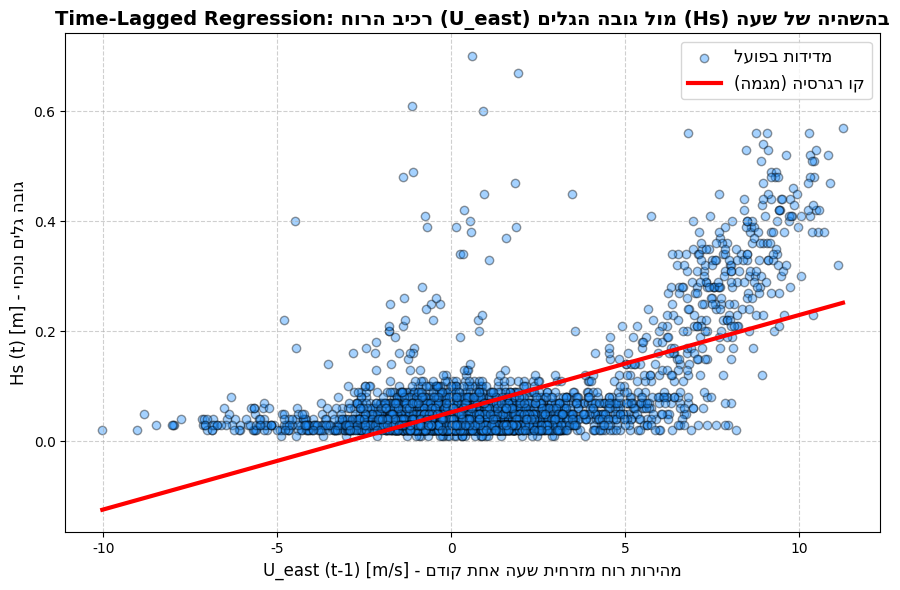

In [11]:
# ==============================================================================
# 📊 CELL: GENERATE TIME-LAGGED REGRESSION PLOT (For the Word Document)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

print("📊 מפיק גרף רגרסיה (Time-Lagged Scatter Plot)...")

# מוודאים שהדאטה זמין מ-Cell 2
if 'df_reg' in globals():
    fig, ax = plt.subplots(figsize=(9, 6))

    x_data = df_reg["U_east_lag"]
    y_data = df_reg["Hs"]

    # 1. ציור הנקודות הכחולות (Scatter)
    ax.scatter(x_data, y_data, color="dodgerblue", alpha=0.4, edgecolor="black", label=he("מדידות בפועל"))

    # 2. חישוב וציור הקו האדום (Trend Line - קו מגמה פשוט להמחשה)
    m, b = np.polyfit(x_data, y_data, 1)
    x_line = np.linspace(x_data.min(), x_data.max(), 100)
    y_line = m * x_line + b

    ax.plot(x_line, y_line, color="red", linewidth=3, label=he("קו רגרסיה (מגמה)"))

    # 3. עיצוב הגרף
    ax.set_title(he("Time-Lagged Regression: רכיב הרוח (U_east) מול גובה הגלים (Hs) בהשהיה של שעה"), fontsize=14, weight="bold")
    ax.set_xlabel(he("U_east (t-1) [m/s] - מהירות רוח מזרחית שעה אחת קודם"), fontsize=12)
    ax.set_ylabel(he("Hs (t) [m] - גובה גלים נוכחי"), fontsize=12)

    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("❌ שגיאה: המשתנה df_reg לא נמצא. אנא הרץ קודם את CELL 2.")